# NB02 — Linkage Atlas: shared join keys → cross-program connectivity

From the column_names captured in NB00's catalog, this notebook identifies the *actual* join surface between BERDL tenants and topics: which canonical identifiers (genome IDs, taxon IDs, sample IDs, KO/pfam/EC, lat/lon, etc.) appear in which tables, and where they overlap.

**Why this matters.** Topic-level co-occurrence (NB01) is a necessary but not sufficient condition for a cross-tenant join. The atlas built here is the *sufficient* condition: it shows, for every (tenant, topic) cell, which join keys are physically present.

**Deliverables:**
1. **`join_keys.json`** — for each of 29 canonical keys, every table that contains it (consumed by NB04).
2. **Key × tenant coverage table** — answers "which join keys can I use to bridge tenant A and tenant B?".
3. **(Tenant, topic) linkage graph** — nodes are (tenant, topic) pairs, edges are weighted by number of shared join keys. Visualizes the *bridge structure* of the lakehouse.
4. **Bridge ranking** — pairs of (tenant, topic) cells with the most shared keys, prioritized for NB04 synergy use cases.

In [1]:
import json
import re
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "data"
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

df = pd.read_csv(DATA / "table_topic_map.csv")
print(f"Loaded {len(df)} tables")

Loaded 1740 tables


## 1. Define and scan canonical join keys

Each key is a regex matched against `column_names` (case-insensitive, exact column-name match per pipe-separated entry). The regex set was iteratively widened by spot-checking column-name distributions in NB00; it covers genome / taxonomy / sample / environmental / annotation / pathway / biochemistry / protein / phage / literature IDs.

In [2]:
KEYS = [
    ("genome_id",         r"^(genome_id|genomeid)$"),
    ("assembly_acc",      r"^(assembly_accession|assembly_id|asm_accession)$"),
    ("gcf_gca",           r"^(gcf|gca|gcf_accession|gca_accession|gcf_gca|refseq_accession|genbank_accession)$"),
    ("ncbi_taxon_id",     r"^(ncbi_taxon_id|ncbi_taxonomy_id|tax_id|taxid|taxonomy_id|taxon_id|species_taxid)$"),
    ("gtdb_taxonomy",     r"^(gtdb_taxonomy|gtdb_lineage|gtdb_classification)$"),
    ("genus",             r"^(genus|genus_name)$"),
    ("species",           r"^(species|species_name|sp)$"),
    ("biosample_id",      r"^(biosample_id|biosample|biosample_accession|ncbi_biosample)$"),
    ("sample_id",         r"^(sample_id|sample_name|sampleid)$"),
    ("lat_lon",           r"^(latitude|longitude|lat|lon|geo_lat|geo_long)$"),
    ("envo",              r"^(envo|envo_id|envo_term|env_broad|env_local|env_medium)$"),
    ("isolation_src",     r"^(isolation_source|host_isolation_source|env_feature)$"),
    ("kegg_ko",           r"^(kegg_ko|ko|ko_id|kofam_id|kegg_orthology)$"),
    ("kegg_pathway",      r"^(kegg_pathway|kegg_pathway_id|pathway_id|kegg_module)$"),
    ("pfam",              r"^(pfam|pfam_id|pfam_accession)$"),
    ("cog",               r"^(cog|cog_id|cog_category)$"),
    ("ec_number",         r"^(ec|ec_number|ec_id)$"),
    ("interpro",          r"^(interpro|interpro_id|interpro_accession)$"),
    ("cazy",              r"^(cazy|cazy_family|cazy_id)$"),
    ("eggnog",            r"^(eggnog|eggnog_og|eggnog_id|seed_ortholog)$"),
    ("protein_id",        r"^(protein_id|protein_accession|uniprot_id|uniprot_accession|uniref_id|sequence_id)$"),
    ("gene_cluster_id",   r"^(gene_cluster_id|cluster_id|orthogroup|orthogroup_id)$"),
    ("feature_id",        r"^(feature_id|gene_id|locus_tag)$"),
    ("uvig_phage",        r"^(uvig|phage_id|virus_id|vog_id)$"),
    ("pmid_doi",          r"^(pmid|pubmed_id|doi|paper_id)$"),
    ("compound_id",       r"^(cpd_id|compound_id|metacyc_id|modelseed_id|kegg_compound_id|chebi_id|inchikey)$"),
    ("reaction_id",       r"^(rxn_id|reaction_id|rhea_id|kegg_reaction_id)$"),
    ("kbase_upa",         r"^(source_upa|kbase_type|canonical_blob_uri|upa)$"),
    ("alphafold_pdb",     r"^(pdb_id|alphafold_id|chain_id|af_id)$"),
]

key_to_tables = defaultdict(list)
for _, r in df.iterrows():
    cols = {c.lower() for c in str(r['column_names']).split('|') if c}
    for label, pat in KEYS:
        regex = re.compile(pat)
        if any(regex.fullmatch(c) for c in cols):
            key_to_tables[label].append((r['tenant'], r['primary_topic'], r['database'], r['table']))

len(key_to_tables), "keys with at least one matching table"

(29, 'keys with at least one matching table')

In [3]:
coverage = []
for label, _ in KEYS:
    items = key_to_tables.get(label, [])
    if not items:
        continue
    tenants = sorted({t for t, _, _, _ in items})
    topics  = sorted({p for _, p, _, _ in items})
    coverage.append({
        "key":      label,
        "tables":   len(items),
        "tenants":  len(tenants),
        "topics":   len(topics),
        "tenant_list": ", ".join(tenants),
    })
cov_df = pd.DataFrame(coverage).sort_values(["tenants", "tables"], ascending=False).reset_index(drop=True)
cov_df

,key,tables,tenants,topics,tenant_list
0,sample_id,84,10,10,"arkinlab, enigma, ese, netl, nmdc, phagefoundr..."
1,genome_id,88,9,8,"arkinlab, enigma, globalusers, kbase, kescienc..."
2,feature_id,60,9,9,"arkinlab, enigma, globalusers, kbase, kescienc..."
3,ncbi_taxon_id,56,9,7,"enigma, kbase, kescience, nmdc, phagefoundry, ..."
4,species,23,8,5,"arkinlab, globalusers, kbase, kescience, msysc..."
5,ec_number,21,8,9,"arkinlab, enigma, kbase, kescience, nmdc, phag..."
6,genus,14,8,3,"arkinlab, globalusers, kbase, kescience, msysc..."
7,protein_id,105,7,4,"enigma, globalusers, kbase, kescience, phagefo..."
8,kegg_pathway,17,6,4,"enigma, kbase, kescience, nmdc, phagefoundry, ..."
9,lat_lon,15,6,5,"arkinlab, kescience, msyscolo, netl, refdata, ..."


## 2. Key × tenant heatmap — "which join keys does each tenant use"

A bright cell (key K, tenant T) means tenant T has at least one table with key K, and that key potentially bridges T to any other bright tenant on the same row.

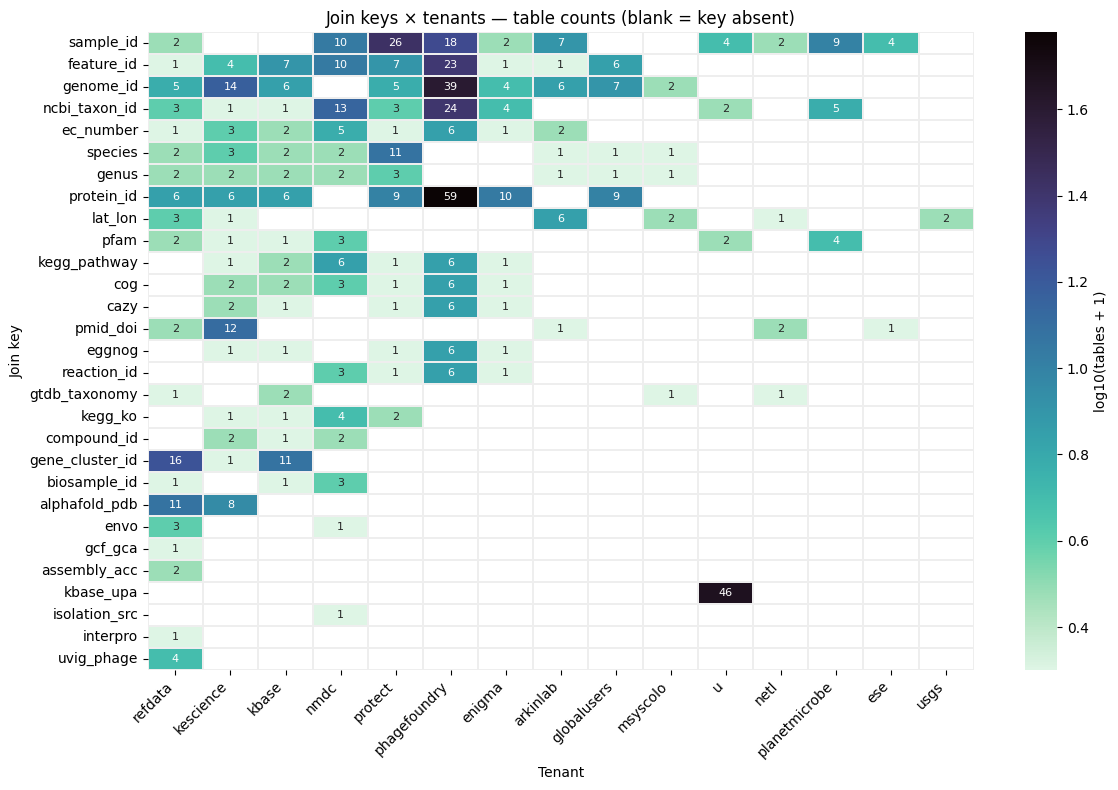

In [4]:
rows_kt = []
for label, items in key_to_tables.items():
    counts = Counter(t for t, _, _, _ in items)
    for tenant, n in counts.items():
        rows_kt.append({"key": label, "tenant": tenant, "tables": n})
kt = pd.DataFrame(rows_kt).pivot_table(index="key", columns="tenant", values="tables", fill_value=0).astype(int)
# Order rows by # tenants (descending), cols by # keys (descending)
kt = kt.loc[(kt > 0).sum(axis=1).sort_values(ascending=False).index]
kt = kt[(kt > 0).sum(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(12, 8))
vals = kt.values.astype(float)
sns.heatmap(
    np.log10(vals + 1), ax=ax, cmap="mako_r",
    annot=kt.values, fmt="d", annot_kws={"size": 8},
    xticklabels=kt.columns, yticklabels=kt.index,
    cbar_kws={"label": "log10(tables + 1)"}, mask=(vals == 0), linewidths=0.3, linecolor="#eee",
)
ax.set_xticklabels(kt.columns, rotation=45, ha="right")
ax.set_yticklabels(kt.index, rotation=0)
ax.set_xlabel("Tenant"); ax.set_ylabel("Join key")
ax.set_title("Join keys × tenants — table counts (blank = key absent)")
fig.tight_layout()
fig.savefig(FIGURES / "nb02_key_tenant_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

## 3. (Tenant, topic) linkage graph

Nodes are (tenant, topic) cells that have ≥ 1 table. An edge connects two cells when they share **at least one join key**; edge weight = number of distinct shared keys. This is the bridge structure of the lakehouse — the connected components tell you which (tenant, topic) cells can join to each other through existing identifiers.

In [5]:
# Per (tenant, topic) cell, accumulate the set of join keys observed.
cell_keys = defaultdict(set)
cell_tables = Counter()
for label, items in key_to_tables.items():
    for tenant, topic, _, _ in items:
        cell_keys[(tenant, topic)].add(label)
for _, r in df.iterrows():
    cell_tables[(r['tenant'], r['primary_topic'])] += 1

# Drop personal scratch / unclassified for clarity.
DROP_TENANTS = {"u", "globalusers", "lambda", "evaluation"}
DROP_TOPICS  = {"unclassified", "system"}

cells = [c for c in cell_keys.keys() if c[0] not in DROP_TENANTS and c[1] not in DROP_TOPICS]

G = nx.Graph()
for c in cells:
    G.add_node(c, size=cell_tables[c])
for a, b in combinations(cells, 2):
    shared = cell_keys[a] & cell_keys[b]
    if shared:
        G.add_edge(a, b, weight=len(shared), keys=sorted(shared))

print(f"Nodes (tenant,topic cells): {G.number_of_nodes()}")
print(f"Edges (≥1 shared key):       {G.number_of_edges()}")
print(f"Density:                     {nx.density(G):.2%}")
print(f"Connected components:        {nx.number_connected_components(G)}")

Nodes (tenant,topic cells): 59
Edges (≥1 shared key):       592
Density:                     34.60%
Connected components:        1


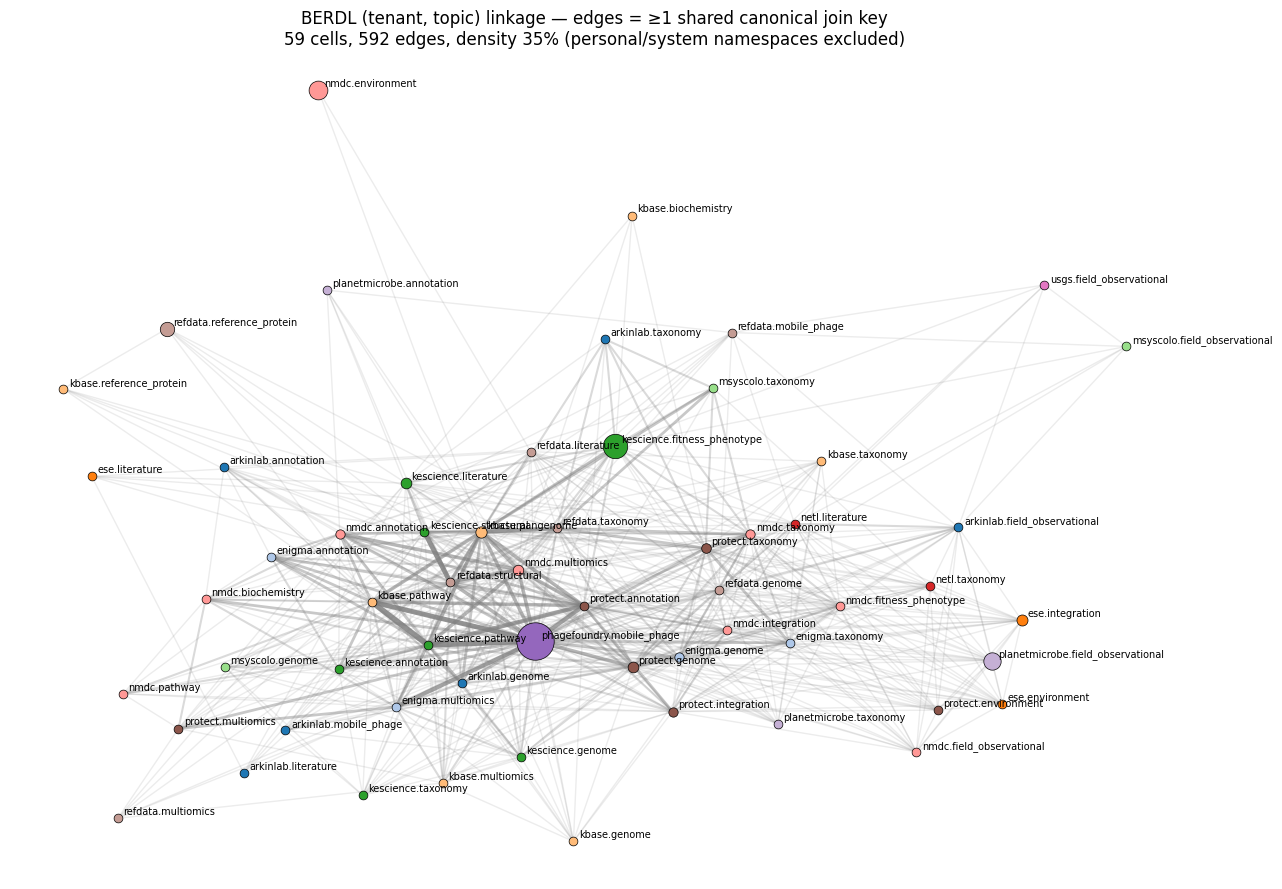

In [6]:
# Color nodes by tenant.
tenants = sorted({n[0] for n in G.nodes})
palette = sns.color_palette("tab20", n_colors=len(tenants))
color_of = {t: palette[i] for i, t in enumerate(tenants)}
node_colors = [color_of[n[0]] for n in G.nodes]
node_sizes  = [max(40, G.nodes[n]["size"] * 3) for n in G.nodes]

edge_weights = np.array([G[u][v]["weight"] for u, v in G.edges])
edge_widths  = 0.5 + 0.5 * edge_weights
edge_alphas  = np.clip(edge_weights / edge_weights.max(), 0.15, 0.85)

pos = nx.spring_layout(G, seed=11, k=0.55, iterations=120)
fig, ax = plt.subplots(figsize=(13, 9))
for (u, v), w, a in zip(G.edges, edge_widths, edge_alphas):
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]], color="grey", linewidth=w, alpha=a, zorder=1)
for n, color, size in zip(G.nodes, node_colors, node_sizes):
    ax.scatter(*pos[n], s=size, color=color, edgecolor="black", linewidth=0.5, zorder=2)
    ax.annotate(f"{n[0]}.{n[1]}", pos[n], xytext=(4, 3), textcoords="offset points", fontsize=7, zorder=3)

ax.set_axis_off()
ax.set_title(
    "BERDL (tenant, topic) linkage — edges = ≥1 shared canonical join key\n"
    f"{G.number_of_nodes()} cells, {G.number_of_edges()} edges, density {nx.density(G):.0%} "
    "(personal/system namespaces excluded)"
)
fig.tight_layout()
fig.savefig(FIGURES / "nb02_linkage_graph.png", dpi=140, bbox_inches="tight")
plt.show()

## 4. Bridge ranking — best (tenant, topic) pairs to anchor a cross-program analysis

For each edge, list the source/destination cells, the number of shared keys, and the actual key names. The top of this list is the prioritized input for NB04 synergy use cases.

In [7]:
bridges = []
for u, v, data in G.edges(data=True):
    # Only keep cross-tenant bridges — same-tenant joins are intra-program.
    if u[0] == v[0]:
        continue
    bridges.append({
        "tenant_a": u[0], "topic_a": u[1],
        "tenant_b": v[0], "topic_b": v[1],
        "shared_keys": data["weight"],
        "keys":       ", ".join(data["keys"]),
    })
bridges_df = (
    pd.DataFrame(bridges)
      .sort_values("shared_keys", ascending=False)
      .reset_index(drop=True)
)
print(f"Cross-tenant bridges: {len(bridges_df)}")
bridges_df.head(25)

Cross-tenant bridges: 536


,tenant_a,topic_a,tenant_b,topic_b,shared_keys,keys
0,kbase,pathway,kescience,pathway,7,"cazy, cog, ec_number, eggnog, genome_id, kegg_..."
1,kescience,pathway,phagefoundry,mobile_phage,7,"cazy, cog, ec_number, eggnog, feature_id, geno..."
2,refdata,structural,kescience,structural,6,"alphafold_pdb, gene_cluster_id, ncbi_taxon_id,..."
3,kbase,pathway,phagefoundry,mobile_phage,6,"cazy, cog, ec_number, eggnog, genome_id, kegg_..."
4,kbase,pangenome,refdata,taxonomy,5,"gene_cluster_id, genome_id, genus, gtdb_taxono..."
5,phagefoundry,mobile_phage,protect,annotation,5,"cazy, cog, ec_number, feature_id, sample_id"
6,enigma,multiomics,phagefoundry,mobile_phage,5,"feature_id, genome_id, kegg_pathway, protein_i..."
7,kescience,pathway,protect,annotation,5,"cazy, cog, ec_number, feature_id, kegg_ko"
8,phagefoundry,mobile_phage,refdata,structural,4,"ec_number, feature_id, ncbi_taxon_id, protein_id"
9,phagefoundry,mobile_phage,nmdc,multiomics,4,"cog, ec_number, feature_id, ncbi_taxon_id"


In [8]:
# Persist for NB03 / NB04 consumption.
(DATA / "join_keys.json").write_text(json.dumps({
    label: [{"tenant": t, "topic": p, "db": d, "table": tb} for t, p, d, tb in items]
    for label, items in key_to_tables.items()
}, indent=1))
bridges_df.to_csv(DATA / "cross_tenant_bridges.csv", index=False)
cov_df.to_csv(DATA / "join_key_coverage.csv", index=False)
print("Saved:")
for f in ["join_keys.json", "cross_tenant_bridges.csv", "join_key_coverage.csv"]:
    print(f"  data/{f} — {(DATA / f).stat().st_size:,} bytes")

Saved:
  data/join_keys.json — 91,558 bytes
  data/cross_tenant_bridges.csv — 29,377 bytes
  data/join_key_coverage.csv — 1,788 bytes


## 5. Findings

**Where the join surface is dense:**
- **`sample_id`** (10 tenants, 10 topics, 84 tables) — the single most cross-cutting key in BERDL. Connects ENIGMA SDT/DDT, PhageFoundry strain samples, NMDC biosamples, NETL/USGS produced-water samples, Planet Microbe, MSysColo. *Caveat:* `sample_id` is a generic name — schemas vary, so joins need value-space audits before they can be executed in SQL.
- **`genome_id`** (9 tenants, 8 topics, 88 tables) — the workhorse for genome ↔ pangenome ↔ phenotype ↔ annotation joins. KBase, KE Science, ENIGMA, NMDC, PhageFoundry, PROTECT all use it. This is the cleanest bridge into KBase's pangenome / biochemistry reference.
- **`ncbi_taxon_id`** (9 tenants, 7 topics, 56 tables) — the universal taxonomy bridge. Spans every major tenant; the standard key to layer NMDC environmental abundance onto FitnessBrowser growth data.
- **`feature_id` / `locus_tag`** (9 tenants, 9 topics, 60 tables) — gene-level bridge. The natural key for cross-tenant comparative annotation.
- **`ec_number`** (8 tenants, 9 topics, 21 tables) — enzymatic-function bridge with the broadest topic surface; rare for being explicitly biochemical.

**Where the join surface is thin / surprising:**
- **`assembly_accession` and `gcf_gca`** only appear in `refdata` — the canonical NCBI accession is essentially absent from the other tenants. Cross-tenant joins instead route through `genome_id`, which means the original NCBI provenance is one indirection away.
- **`gtdb_taxonomy` appears in only 5 tables across 4 tenants** — the modern microbial taxonomy is **less widely indexed than NCBI**, even though every modern MAG pipeline emits GTDB. Action: when joining to old datasets, expect to convert.
- **`envo`-style ontology IDs only in NMDC and refdata** — environmental ontology coverage is shallow. Planet Microbe / ENIGMA use ad-hoc `isolation_source` strings instead.
- **`uvig_phage` is refdata-only** — phage IDs are mono-tenant. PhageFoundry → host genome joins must go through `genome_id` (host MAG), not phage ID.
- **`kbase_upa` is u-only** (46 tables) — KBase Workspace lineage is per-user, not a cross-tenant join key.

**Bridge ranking — top cross-tenant pairs by shared-key count:**
- See the `bridges` table above; the densest cross-tenant cells (≥4 shared keys) are the prioritized anchors for NB04 use cases.
- The `linkage_graph` figure shows a small number of *hub* cells (KBase reference data, refdata taxonomy, KE Science fitness) connected to many spokes — these are the cells that, if instrumented (e.g., with column-level documentation), unlock the most cross-program analyses.

### Artifacts for downstream notebooks
- **`data/join_keys.json`** — `{key: [{tenant, topic, db, table}, …]}`
- **`data/cross_tenant_bridges.csv`** — ranked (tenant×topic) bridge pairs with key inventory.
- **`data/join_key_coverage.csv`** — per-key coverage stats (tables, tenants, topics).

### Caveats (this is column-presence, not value-overlap)
The linkage graph proves the **schema** allows a join. It does NOT prove the join's value-space overlaps in any useful way. For example, two tables both with `genome_id` may use disjoint identifier conventions (KBase UPA vs NCBI accession vs MAG hash). NB04 will sample-execute the top-ranked bridges to confirm value-space overlap before claiming a synergy use case.